In [6]:
from gudhi import RipsComplex
import numpy as np
import matplotlib.pyplot as plt

from persim import PersistenceImager
import persim.images_weights as weights

In [7]:
def compute_Rips(points, max_edge = 10):
    rips = RipsComplex(points=points, max_edge_length = max_edge)
    st = rips.create_simplex_tree(max_dimension=2)

    return st

def compute_Persistence_barcode(A):
    fil_A = compute_Rips(A)
    fil_A.persistence()

    bar_a0 = fil_A.persistence_intervals_in_dimension(0)
    bar_A0 = [bar for bar in bar_a0 if bar[1] != np.inf]
    bar_a1 = fil_A.persistence_intervals_in_dimension(1)
    bar_A1 = [bar for bar in bar_a1 if bar[1] != np.inf]

    bar0 = []
    for bar in bar_A0:
        if bar[1]-bar[0] > 1e-5:
            bar0.append([bar[0], bar[1]])
    bar1 = []
    for bar in bar_A1:
        if bar[1]-bar[0] > 1e-5:
            bar1.append([bar[0], bar[1]])

    bar_A = {}
    bar_A[0] = bar0
    bar_A[1] = bar1

    return bar_A

def compute_PIs(barcodes, max_eps=10, px_res=0.1, sigma=0.05, normalization=False):
    keys = barcodes.keys()

    for key in keys:
        if len(barcodes[key]) == 0:
            barcodes[key] = np.zeros((0, 2))

    vector = {}

    # =========================================================================
    # H0 Persistence Image
    # 논문: birth_range=(0, 1), pers_range=(0, max_eps), skew=False
    # =========================================================================
    pers_imager_h0 = PersistenceImager()
    pers_imager_h0.pixel_size = px_res
    pers_imager_h0.birth_range = (0, 0.01)
    pers_imager_h0.pers_range = (0, max_eps)
    pers_imager_h0.weight = weights.persistence
    pers_imager_h0.weight_params = {'n': 1}
    pers_imager_h0.kernel_params = {'sigma': [[sigma, 0], [0, sigma]]}
    
    bars_h0 = np.array(barcodes[0])
    if len(bars_h0) > 0:
        # H0는 skew=False (이미 birth-persistence 형태로 간주)
        img_h0 = pers_imager_h0.transform(bars_h0, skew=True)
    else:
        img_h0 = np.zeros((int(1/px_res), int(max_eps/px_res)))
    
    # 논문: np.mean(img, axis=0) - birth 축을 따라 평균
    img0_1d = np.mean(img_h0, axis=0)

    # =========================================================================
    # H1 Persistence Image
    # 논문: birth_range=(0, max_eps), pers_range=(0, max_eps/2), skew=True
    # =========================================================================
    pers_imager_h1 = PersistenceImager()
    pers_imager_h1.pixel_size = px_res
    pers_imager_h1.birth_range = (0, max_eps)
    pers_imager_h1.pers_range = (0, max_eps / 2)
    pers_imager_h1.weight = weights.persistence
    pers_imager_h1.weight_params = {'n': 1}
    pers_imager_h1.kernel_params = {'sigma': [[sigma, 0], [0, sigma]]}
    
    bars_h1 = np.array(barcodes[1])
    if len(bars_h1) > 0:
        # H1은 skew=True ((birth, death) → (birth, persistence) 변환)
        img_h1 = pers_imager_h1.transform(bars_h1, skew=True)
    else:
        img_h1 = np.zeros((int(max_eps/px_res), int((max_eps/2)/px_res)))

    # =========================================================================
    # Normalization & Output
    # =========================================================================
    if normalization:
        if np.max(img0_1d) > 0:
            vector[0] = img0_1d / np.max(img0_1d)
        else:
            vector[0] = img0_1d
            
        if np.max(img_h1) > 0:
            vector[1] = img_h1.flatten() / np.max(img_h1)
        else:
            vector[1] = img_h1.flatten()
    else:
        vector[0] = img0_1d
        vector[1] = img_h1.flatten()

    return vector

def visualize_PIs(PIs, max_eps=10, px_res=0.1):
    import matplotlib.pyplot as plt
    
    # H0: shape (100,) - 1D image
    # 논문에서 mean(axis=0)으로 1D가 되었으므로 그대로 plot
    h0_img = PIs[0]
    h0_length = int(max_eps / px_res)  # 100
    
    # H1: shape (5000,) → reshape to (100, 50)
    h1_birth_bins = int(max_eps / px_res)  # 100
    h1_pers_bins = int((max_eps / 2) / px_res)  # 50
    h1_img = PIs[1].reshape((h1_birth_bins, h1_pers_bins))
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # H0 (1D plot)
    axes[0].plot(h0_img, 'b-', linewidth=1.5)
    axes[0].fill_between(range(len(h0_img)), h0_img, alpha=0.3)
    axes[0].set_title(f'H0 Persistence Image (1D)\nLength: {h0_length}')
    axes[0].set_xlabel('Persistence (Bin Index)')
    axes[0].set_ylabel('Intensity')
    axes[0].set_xlim([0, h0_length])
    axes[0].grid(True, alpha=0.3)
    
    # H1 (2D image)
    im = axes[1].imshow(h1_img.T, cmap='hot', origin='lower', aspect='auto')
    axes[1].set_title(f'H1 Persistence Image (2D)\nResolution: ({h1_birth_bins}, {h1_pers_bins})')
    axes[1].set_xlabel('Birth (Bin Index)')
    axes[1].set_ylabel('Persistence (Bin Index)')
    plt.colorbar(im, ax=axes[1], label='Intensity')
    
    plt.tight_layout()
    plt.show()

In [ ]:
A = np.random.rand(120, 2)*20
B = np.random.rand(80, 2)*20

In [ ]:
PB_total = compute_Persistence_barcode(np.concatenate([A, B], axis=0))
PB_A = compute_Persistence_barcode(A)
PB_B = compute_Persistence_barcode(B)

PI_total = compute_PIs(PB_total, normalization = False)
PI_A = compute_PIs(PB_A, normalization = False)
PI_B = compute_PIs(PB_B, normalization = False)

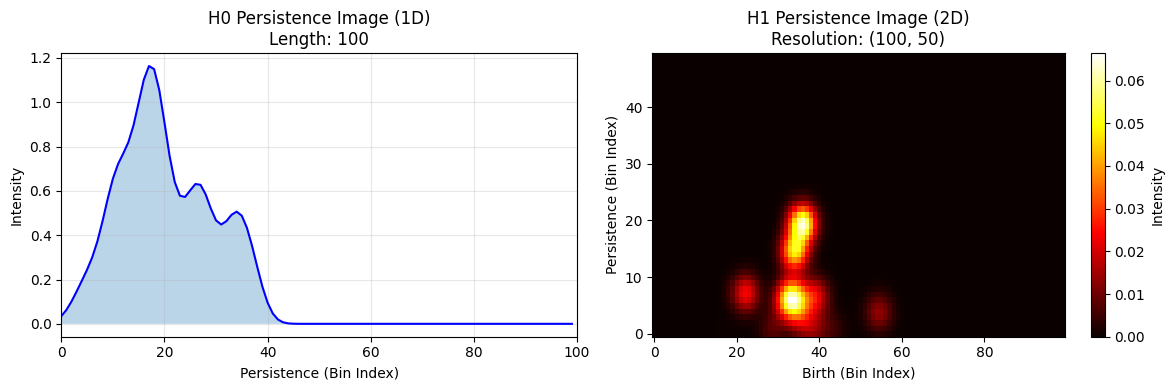

In [28]:
visualize_PIs(PI_B)